<a href="https://colab.research.google.com/github/IanPerigoUERN/NexVisual/blob/main/NexVisual_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transfering learning**

# **Detecção de objetos**

# **Segmentação semântica**

In [50]:
!pip install opencv-python

from google.colab import drive

import os

import numpy as np

import matplotlib.pyplot as plt

import cv2

from google.colab.patches import cv2_imshow

!pip install torch torchvision

import torch
import torchvision

from torchvision.models import resnet18, ResNet18_Weights

import torch.nn as nn


drive.mount('/content/drive')


directory = '/content/drive/MyDrive/nexvisual_files/'


os.makedirs(directory, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
# Como vamos usar o resnet18 iremos fazer o pré-processamento
preprocess= torchvision.transforms.Compose([
    torchvision.transforms.Resize((224,224)),
    torchvision.transforms.Grayscale(num_output_channels=3),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [28]:
# Definir o pré-processamento dos dados.
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
                                            torchvision.transforms.Resize(256),
                                            torchvision.transforms.CenterCrop(224)])

# Carregar o conjunto de treino.
train_data = torchvision.datasets.MNIST(
    root='./data',      # Pasta para salvar os dados.
    train=True,         # Busca pelo sub conjunto de treino.
    download=True,      # Download do dados se necessário.
    transform=preprocess # Transformação a ser aplicada.
)

# Carregar o conjunto de teste.
test_data = torchvision.datasets.MNIST(
    root='./data',      # Pasta para salvar os dados.
    train=False,        # Busca pelo sub conjunto de teste.
    download=True,      # Download do dados se necessário.
    transform=preprocess # Transformação a ser aplicada.
)

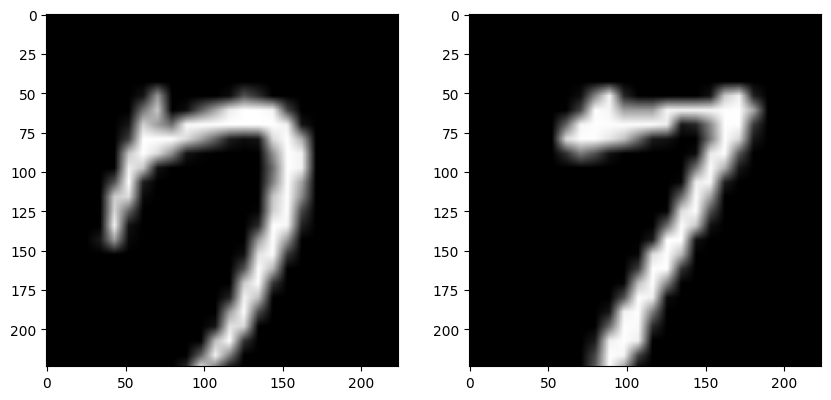

In [17]:
# Visualizar duas imagens aleatórias da base de dados.
indexes = [np.random.randint(0, len(train_data)), np.random.randint(0, len(train_data))]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(train_data[indexes[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1].imshow(train_data[indexes[1]][0].numpy().transpose(1,2,0), cmap="gray")
plt.show()

In [18]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [20]:
model.fc = nn.Linear(
    model.fc.in_features,
    10
)

print(model.fc.in_features)

512


In [21]:
for param in model.parameters():
    param.requires_grad = False

In [22]:
# optimizer = torch.optim.Adam(
#     model.fc.parameters(),
#     lr=1e-3 #taxa de aprendizado
# )

In [30]:

# Vamos colocar o modelo em modo de avaliação.
model.eval()

# Criar o dataloader para iterar nos dados.
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

# Validar dispositivo de treino.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Colocar modelo no dispositivo.
model.to(device)

# Vamos medir a performance do modelo sem o refinamento.
correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    # Coloando os dados nos dispositivos.
    data = data.to(device)
    target = target.to(device)

    # Processando os dados.
    output = model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct = correct + 1

# Calcula acurácia.
acc = correct/len(test_data)
print(f"Acurácia com modelo sem refinamento: {acc * 100}%")

Acurácia com modelo sem refinamento: 13.99%


In [34]:
########################
## Processo de treino. ##
########################

# Ensure the parameters of the newly assigned final layer are trainable
for param in model.fc.parameters():
    param.requires_grad = True

# Criando otimizador.
optimizer = torch.optim.SGD(model.fc.parameters(), lr=0.0001) # ADAM 18 min  SGD é muito mais lento

# Definindo função de perda.
loss_criterion = torch.nn.CrossEntropyLoss()

# Criar o dataloader de treino.
batch_size = 16 # Define quantas instâncias serão processadas em uma passada do modelo.
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)

# Laço de treinamento.
epochs = 1
for epoch in range(epochs):
    # Colocar modelo em modo de treino.
    model.train()

    # Colocar modelo no dispositivo.
    model.to(device)

    # Função de perda e Acurácia para epóca.
    train_loss = 0.0
    train_acc = 0.0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Move os dados para o dispositivo de computação.
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Limpando os gradientes do otimizador.
        optimizer.zero_grad()

        # Passando informação no modelo.
        outputs = model(inputs)

        # Calculando a função de perda.
        loss = loss_criterion(outputs, labels)

        # Backpropagation dos gradientes.
        loss.backward()

        # Atualização dos parâmetros.
        optimizer.step()

        # Compute the total loss for the batch and add it to train_loss
        train_loss += loss.item() * inputs.size(0)

        # Calcule a acurácia.
        _, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))

        # Calcular a acurácia do batch.
        acc = torch.mean(correct_counts.type(torch.FloatTensor))

        # Calcular a acurácia total.
        train_acc += acc.item() * inputs.size(0)
        print("Batch number: {:03d}/{:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}".format(batch_idx, len(train_data) // batch_size, loss.item(), acc.item()))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch number: 000/3750, Training: Loss: 2.5707, Accuracy: 0.0625
Batch number: 001/3750, Training: Loss: 2.4954, Accuracy: 0.1250
Batch number: 002/3750, Training: Loss: 2.3580, Accuracy: 0.1875
Batch number: 003/3750, Training: Loss: 2.3444, Accuracy: 0.1250
Batch number: 004/3750, Training: Loss: 2.7059, Accuracy: 0.0625
Batch number: 005/3750, Training: Loss: 2.4577, Accuracy: 0.0625
Batch number: 006/3750, Training: Loss: 2.2126, Accuracy: 0.0000
Batch number: 007/3750, Training: Loss: 2.3391, Accuracy: 0.1250
Batch number: 008/3750, Training: Loss: 2.3968, Accuracy: 0.0625
Batch number: 009/3750, Training: Loss: 2.5661, Accuracy: 0.0625
Batch number: 010/3750, Training: Loss: 2.3034, Accuracy: 0.2500
Batch number: 011/3750, Training: Loss: 2.5369, Accuracy: 0.0625
Batch number: 012/3750, Training: Loss: 2.3973, Accuracy: 0.1250
Batch number: 013/3750, Training: Loss: 2.2938, Accuracy: 0.1875
Batch number: 014/3750, Training: Loss: 2.6732, Accuracy: 0.0000
Batch number: 015/3750, T

In [35]:
# Vamos colocar o modelo em modo de avaliação.
model.eval()

# Criar o dataloader para iterar nos dados.
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

# Vamos medir a performance do modelo sem o refinamento.
correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    # Coloando os dados nos dispositivos.
    data = data.to(device)
    target = target.to(device)

    # Processando os dados.
    output = model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct = correct + 1

# Calcula acurácia.
acc = correct/len(test_data)
print(f"Acurácia com modelo com refinamento: {acc * 100}%")

Acurácia com modelo com refinamento: 66.3%


# **Detecção de Objetos**

In [51]:
!pip install ultralytics

In [52]:
import ultralytics

In [40]:
model_detect = ultralytics.YOLO("yolo11n.pt")

In [53]:
image = cv2.imread(directory + 'india.jpg')


0: 640x544 1 person, 25 cars, 1 truck, 401.9ms
Speed: 27.2ms preprocess, 401.9ms inference, 21.4ms postprocess per image at shape (1, 3, 640, 544)


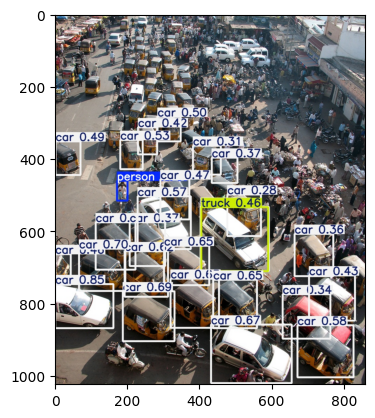

In [42]:
results = model_detect(image)

for i, result in enumerate(results):
    # Salva os resultados em uma imagem no disco.
    result.save(filename=f"results_{i}.jpg")

# Carrega a imagem que acabou de ser salva para visualizarmos.
results_image = cv2.imread("results_0.jpg")
plt.imshow(cv2.cvtColor(results_image, cv2.COLOR_BGR2RGB))

# **Segmentação semântica**

In [54]:
# Carregar o modelo SAM.
model_sam = ultralytics.SAM("sam_b.pt")



In [55]:
# Roda a inferência do modelo SAM.
results = model_sam(image)

for i, result in enumerate(results):
    # Salva os resultados em uma imagem no disco.
    result.save(filename=f"results_{i}.jpg", boxes=False)

# Carrega a imagem que acabou de ser salva para visualizarmos.
results_image = cv2.imread("results_0.jpg")



KeyboardInterrupt: 

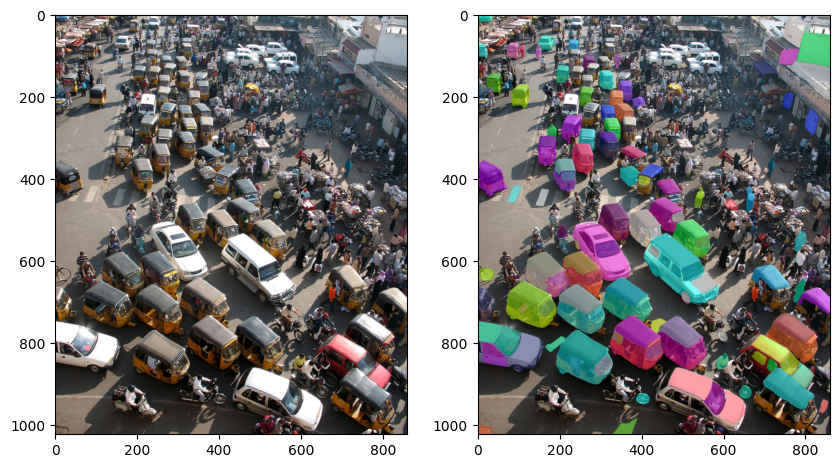

In [47]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(results_image, cv2.COLOR_BGR2RGB))
plt.show()

In [56]:
# Modelo de segmentação semântica do torchvision

# Vamos usar o deeplabv3_resnet


from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights
)

weights = DeepLabV3_ResNet50_Weights.DEFAULT

model = deeplabv3_resnet50(
    weights=weights
)

model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [134]:
from PIL import Image

# Convert the numpy array image to a PIL Image

image = cv2.imread(directory + 'carros2.jpg')

pil_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

preprocess = weights.transforms()

input_tensor = preprocess(pil_image)

input_batch = input_tensor.unsqueeze(0)

In [135]:
with torch.no_grad():
    output = model(input_batch)

In [136]:
mask = output['out'][0]
print(mask.shape)

torch.Size([21, 520, 779])


In [137]:
prediction = mask.argmax(0)

print(prediction.shape)

torch.Size([520, 779])


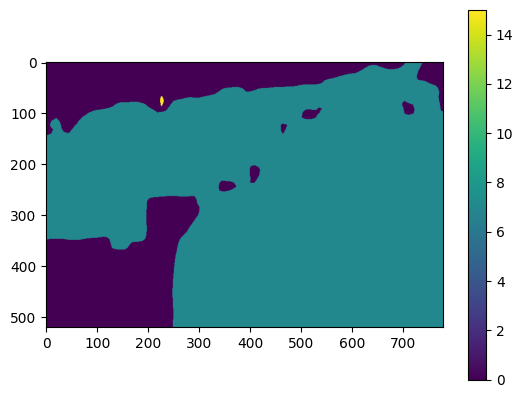

In [138]:


plt.imshow(prediction.cpu().numpy())
plt.colorbar()
plt.show()

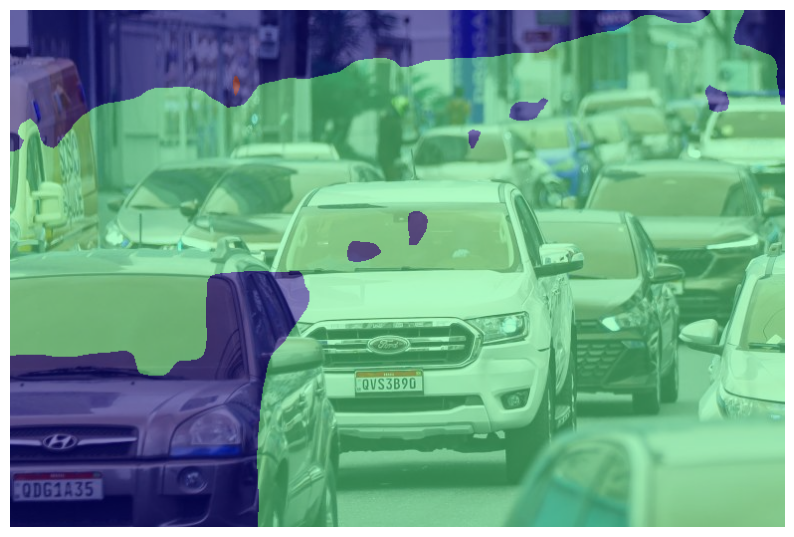

In [139]:
plt.figure(figsize=(10,10))

plt.imshow(image)




plt.imshow(
    prediction.cpu(),
    alpha=0.5,
    cmap="jet"
)

plt.axis("off")
plt.show()

In [144]:
VOC_CLASSES = [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "potted plant",
    "sheep",
    "sofa",
    "train",
    "tv/monitor"
]

classes = torch.unique(prediction)

for c in classes:
    print(c.item(), VOC_CLASSES[c])

0 background
7 car
15 person


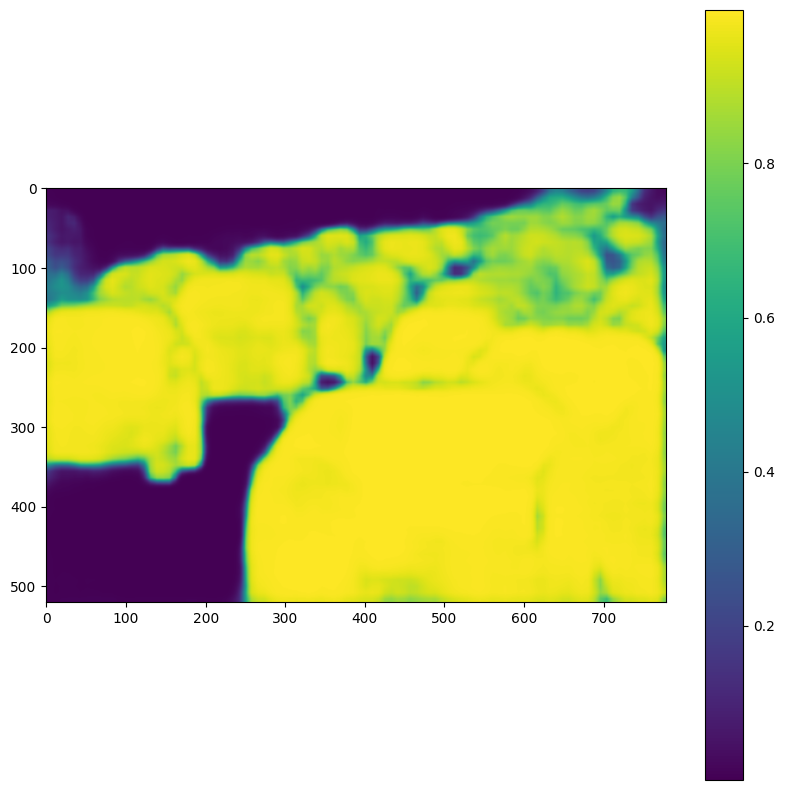

In [145]:
probs = torch.softmax(output['out'][0], dim=0)

car_prob = probs[7]

plt.figure(figsize=(10,10))
plt.imshow(car_prob.cpu())
plt.colorbar()
plt.show()

In [146]:
print(input_tensor.shape)

torch.Size([3, 520, 779])


In [147]:
probs = torch.softmax(output['out'][0], dim=0)

car_prob = probs[7].cpu().numpy()

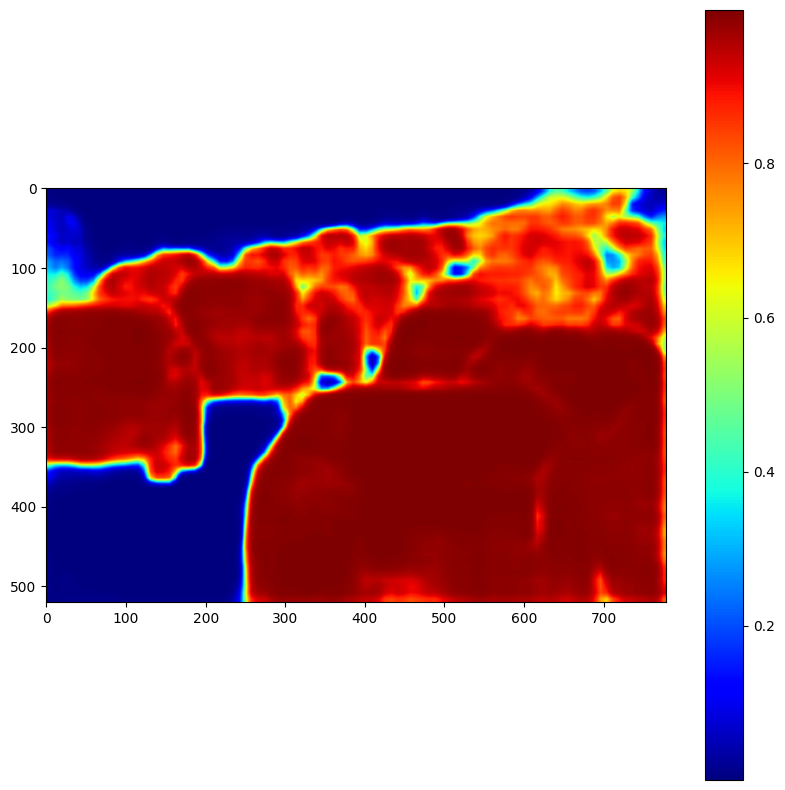

In [148]:
plt.figure(figsize=(10,10))
plt.imshow(car_prob, cmap='jet')
plt.colorbar()
plt.show()





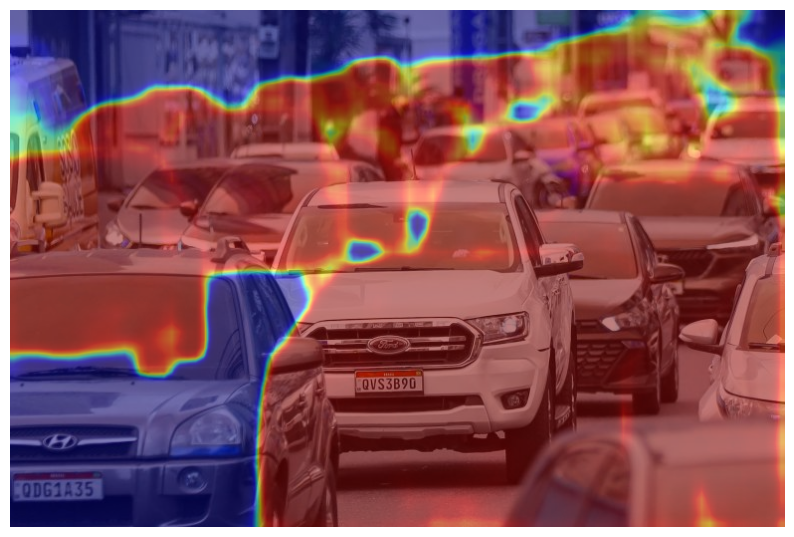

In [149]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.imshow(
    car_prob,
    alpha=0.5,
    cmap="jet"
)

plt.axis("off")
plt.show()

In [152]:
from PIL import Image

# Convert the numpy array image to a PIL Image

image = cv2.imread(directory + 'carro3.png')

pil_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

preprocess = weights.transforms()

input_tensor = preprocess(pil_image)

input_batch = input_tensor.unsqueeze(0)

with torch.no_grad():
    output = model(input_batch)

mask = output['out'][0]
print(mask.shape)


prediction = mask.argmax(0)

print(prediction.shape)

torch.Size([21, 520, 760])
torch.Size([520, 760])


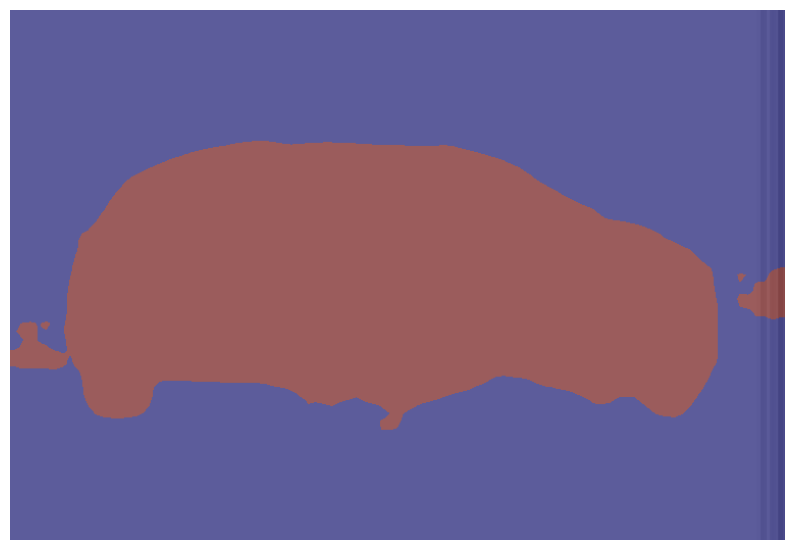

In [153]:
plt.figure(figsize=(10,10))

plt.imshow(image)




plt.imshow(
    prediction.cpu(),
    alpha=0.5,
    cmap="jet"
)

plt.axis("off")
plt.show()

# **Aparentemente nosso modelo com resnet precisa de segmentação de instância ao invés apenas de segmentação semântica. Pois quando foi exibido uma imagem de trânsito com vários carros, a segmentação ficava como uma grande mancha entre as predições com maiores valores, e não instanciava cada carro individualmente**